# 5 Modeling<a id='5_Modeling'></a>

## 5.3 Imports<a id='5.3_Imports'></a>

In [1]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import __version__ as sklearn_version
from sklearn.model_selection import cross_validate

In [2]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, f_regression
import datetime

In [3]:
#return the first 5 and last 5 rows of this dataframe
def p(df_):
    if df_.shape[0] > 6:
        print(df_.shape)
        return pd.concat([df_.head(), df_.tail()])
    else:
        return df_

def rcp(file_, pd_=None, ic_=None):
    if (pd_ == None) and (ic_ == None):
        return pd.read_csv(os.path.join('..', 'processed_data', file_))
    elif (pd_ != None) and (ic_ == None):
        return pd.read_csv(os.path.join('..', 'processed_data', file_), parse_dates=pd_)
    elif (pd_ != None) and (ic_ != None):
        return pd.read_csv(os.path.join('..', 'processed_data', file_), parse_dates=pd_, index_col = ic_)
    else:
        return pd.read_csv(os.path.join('..', 'processed_data', file_), index_col = ic_)
    
def rcr(file_, pd_=None):
    if pd_ == None:
        return pd.read_csv(os.path.join('..', 'raw_data', file_))
    else:
        return pd.read_csv(os.path.join('..', 'raw_data', file_), parse_dates=pd_)
    
#sort dataframe by column
def s(df_, column_):
    return df_.sort_values(column_)

#reset index and sort dataframe by column
def sr(df_, column_, ascending_=True):
    df_ = df_.sort_values(column_, ascending=ascending_)
    return df_.reset_index(drop=True)

#print length of list
def pl(list_):
    print(len(list_))
    return list_

#print length of dictionary
def pdc(dict_):
    print(len(dict_))
    return dict_

## 5.4 Load Model<a id='5.4_Load_Model'></a>

In [4]:
# This isn't exactly production-grade, but a quick check for development
# These checks can save some head-scratching in development when moving from
# one python environment to another, for example
expected_model_version = '1.0'
model_path = os.path.join('..','models', 'nba_spread_a_model_158C.pkl')
if os.path.exists(model_path):
    with open(model_path, 'rb') as f:
        model = pickle.load(f)
    if model.version != expected_model_version:
        print("Expected model version doesn't match version loaded")
    if model.sklearn_version != sklearn_version:
        print("Warning: model created under different sklearn version")
else:
    print("Expected model not found")

## 5.5 Load Data<a id='5.5_Load_Data'></a>

In [5]:
df_train = rcp('158C_train_split.csv', None, 0)
p(df_train)

(7186, 521)


,away_home_a,E_OFF_RATING_cma_diff,OFF_RATING_cma_diff,E_DEF_RATING_cma_diff,DEF_RATING_cma_diff,E_NET_RATING_cma_diff,NET_RATING_cma_diff,AST_PCT_cma_diff,AST_TOV_cma_diff,AST_RATIO_cma_diff,...,lc_max_USG_PCT_cmax999_diff,lc_max_E_USG_PCT_cmax999_diff,lc_max_E_PACE_cmax999_diff,lc_max_PACE_cmax999_diff,lc_max_PACE_PER40_cmax999_diff,lc_max_POSS_cmax999_diff,lc_max_PIE_cmax999_diff,w_pct_cmax999_diff,away_home__cmax999_diff,spread_a
3134,-0.999416,-0.018902,-0.016231,1.321667,1.343521,-1.228430,-1.303603,-1.318706,-1.481543,-1.903444,...,0.904651,0.009741,0.150481,0.215360,0.215368,-1.200145,0.467431,-0.053990,0.00089,11
8383,-0.999416,-0.099050,-0.203595,-0.808132,-0.713716,0.644865,0.483580,1.728190,1.736950,1.631711,...,-0.428094,-0.371421,-0.348885,-0.446480,-0.446478,-0.624224,0.453373,1.769401,0.00089,-10
7423,-0.999416,0.556110,0.547723,0.560475,0.683780,0.017205,-0.111224,0.252549,0.728169,0.622166,...,-0.345217,-0.236893,0.028768,-0.178778,-0.178773,-0.748180,-0.123718,1.329463,0.00089,22
2528,-0.999416,-0.952155,-0.852996,0.086268,0.042980,-0.977366,-0.882992,-0.515762,-0.081084,-0.681277,...,-0.036514,-1.096909,2.674482,1.838574,1.838587,0.753937,-0.327336,0.637737,0.00089,10
10064,-0.999416,-0.095322,-0.018096,0.455715,0.277340,-0.506578,-0.283939,0.008202,-0.123970,0.063248,...,-0.330959,-0.241594,0.177328,0.118828,0.118844,-0.012269,0.228603,-1.119249,0.00089,4
3378,1.000585,-1.174518,-1.003384,1.645557,1.503400,-2.614035,-2.438719,-0.579292,-0.263904,-1.131438,...,0.208814,0.168291,0.166074,0.178267,0.178269,-1.010025,0.304285,1.733432,0.00089,-5
1965,1.000585,0.229928,0.230790,-0.150739,-0.311130,0.351722,0.523296,-0.936250,0.030585,-0.827527,...,-1.260424,-1.068081,0.070658,-0.039882,-0.039907,-0.466190,-0.057586,-0.053990,0.00089,14
1161,-0.999416,-0.466237,-0.596032,-0.951336,-0.901526,0.431830,0.271150,-0.390189,-0.673265,-0.555054,...,0.120866,0.092204,-0.196164,-0.341406,-0.341405,-0.457735,-0.183934,1.329463,0.00089,-8
2771,-0.999416,-1.113941,-1.106853,-0.899436,-0.889968,-0.231041,-0.241453,1.173629,-2.120647,0.444011,...,-0.467199,-0.555595,0.618090,0.537996,0.538014,-0.143546,-0.226737,-0.053990,0.00089,-4
9937,1.000585,0.411658,0.267144,-0.741816,-0.554801,1.066532,0.796684,-0.120345,-0.566747,-0.167305,...,-0.036514,-0.046312,1.417936,1.168349,1.168359,0.544958,-0.277215,1.052773,0.00089,-8


In [6]:
df_test = rcp('158C_test_split.csv', None, 0)
p(df_test)

(3080, 521)


,away_home_a,E_OFF_RATING_cma_diff,OFF_RATING_cma_diff,E_DEF_RATING_cma_diff,DEF_RATING_cma_diff,E_NET_RATING_cma_diff,NET_RATING_cma_diff,AST_PCT_cma_diff,AST_TOV_cma_diff,AST_RATIO_cma_diff,...,lc_max_USG_PCT_cmax999_diff,lc_max_E_USG_PCT_cmax999_diff,lc_max_E_PACE_cmax999_diff,lc_max_PACE_cmax999_diff,lc_max_PACE_PER40_cmax999_diff,lc_max_POSS_cmax999_diff,lc_max_PIE_cmax999_diff,w_pct_cmax999_diff,away_home__cmax999_diff,spread_a
2583,1.000585,0.364128,0.314684,-0.920580,-0.982429,1.188895,1.256641,-1.064798,-0.921805,-0.600467,...,-0.110566,0.094710,0.026897,0.023189,0.023190,-0.762513,-0.143732,0.867390,0.00089,7
9370,-0.999416,-0.726251,-0.886865,-0.028679,-0.236006,-0.661512,-0.653382,-1.661853,-0.376687,-1.774194,...,-5.499134,-4.306353,0.036302,0.137487,0.137491,-1.019397,-0.494562,-1.420841,0.00089,15
5655,-0.999416,-0.544521,-0.381636,0.635441,0.584578,-1.099025,-0.938778,0.475648,0.308365,0.290309,...,-0.776584,-1.208918,2.143169,2.723134,2.723160,-0.379226,-0.587689,-0.053990,0.00089,-1
7258,1.000585,0.291436,0.402306,-1.376142,-1.278108,1.534856,1.621467,-0.564419,0.437857,-0.052028,...,-0.120784,-0.113064,-0.011196,-0.018942,-0.018976,-0.110917,0.770559,2.278512,0.00089,-5
2386,1.000585,-0.012379,-0.009706,0.019376,0.017296,-0.029451,-0.026252,-0.170277,-0.115615,-0.128880,...,-0.036514,-0.046312,-0.000796,-0.014361,-0.014362,-0.063444,0.044397,-0.053990,0.00089,-10
8109,-0.999416,-0.310602,-0.362993,0.036676,-0.020266,-0.326115,-0.342126,0.625443,-0.625227,0.353187,...,0.361121,0.354334,0.057868,0.012284,0.012277,-0.843895,-0.066984,-2.029561,0.00089,2
9743,1.000585,-0.409389,-0.383501,-0.060396,0.109756,-0.334037,-0.486209,0.994087,0.385643,0.772375,...,-1.519613,-1.295497,-0.027634,-0.080562,-0.080572,0.590054,-0.490927,-1.218857,0.00089,24
4546,1.000585,-0.467169,-0.596032,0.630636,0.387137,-1.018917,-0.959097,-0.415686,-1.155725,-0.803074,...,0.781244,0.594295,-1.981492,-1.406324,-1.406320,-0.202023,-0.092424,-0.053990,0.00089,6
4962,-0.999416,-0.389818,-0.352740,-0.339115,-0.285125,-0.055860,-0.073356,-0.408249,-0.988639,-0.031069,...,-0.131111,0.067785,0.140244,0.037836,0.037828,0.203398,0.041960,0.637737,0.00089,10
5706,-0.999416,-0.235114,-0.458073,-0.062318,0.005739,-0.168540,-0.462195,-0.430559,1.448727,-0.052028,...,0.503206,0.592839,-1.058308,0.119384,0.119387,0.046277,0.120739,-0.693145,0.00089,5


In [7]:
X_train = df_train.drop(columns = 'spread_a')
p(X_train)

(7186, 520)


,away_home_a,E_OFF_RATING_cma_diff,OFF_RATING_cma_diff,E_DEF_RATING_cma_diff,DEF_RATING_cma_diff,E_NET_RATING_cma_diff,NET_RATING_cma_diff,AST_PCT_cma_diff,AST_TOV_cma_diff,AST_RATIO_cma_diff,...,lc_max_TS_PCT_cmax999_diff,lc_max_USG_PCT_cmax999_diff,lc_max_E_USG_PCT_cmax999_diff,lc_max_E_PACE_cmax999_diff,lc_max_PACE_cmax999_diff,lc_max_PACE_PER40_cmax999_diff,lc_max_POSS_cmax999_diff,lc_max_PIE_cmax999_diff,w_pct_cmax999_diff,away_home__cmax999_diff
3134,-0.999416,-0.018902,-0.016231,1.321667,1.343521,-1.228430,-1.303603,-1.318706,-1.481543,-1.903444,...,0.113194,0.904651,0.009741,0.150481,0.215360,0.215368,-1.200145,0.467431,-0.053990,0.00089
8383,-0.999416,-0.099050,-0.203595,-0.808132,-0.713716,0.644865,0.483580,1.728190,1.736950,1.631711,...,0.229811,-0.428094,-0.371421,-0.348885,-0.446480,-0.446478,-0.624224,0.453373,1.769401,0.00089
7423,-0.999416,0.556110,0.547723,0.560475,0.683780,0.017205,-0.111224,0.252549,0.728169,0.622166,...,-0.796744,-0.345217,-0.236893,0.028768,-0.178778,-0.178773,-0.748180,-0.123718,1.329463,0.00089
2528,-0.999416,-0.952155,-0.852996,0.086268,0.042980,-0.977366,-0.882992,-0.515762,-0.081084,-0.681277,...,-2.439231,-0.036514,-1.096909,2.674482,1.838574,1.838587,0.753937,-0.327336,0.637737,0.00089
10064,-0.999416,-0.095322,-0.018096,0.455715,0.277340,-0.506578,-0.283939,0.008202,-0.123970,0.063248,...,-0.151972,-0.330959,-0.241594,0.177328,0.118828,0.118844,-0.012269,0.228603,-1.119249,0.00089
3378,1.000585,-1.174518,-1.003384,1.645557,1.503400,-2.614035,-2.438719,-0.579292,-0.263904,-1.131438,...,-1.801946,0.208814,0.168291,0.166074,0.178267,0.178269,-1.010025,0.304285,1.733432,0.00089
1965,1.000585,0.229928,0.230790,-0.150739,-0.311130,0.351722,0.523296,-0.936250,0.030585,-0.827527,...,0.934438,-1.260424,-1.068081,0.070658,-0.039882,-0.039907,-0.466190,-0.057586,-0.053990,0.00089
1161,-0.999416,-0.466237,-0.596032,-0.951336,-0.901526,0.431830,0.271150,-0.390189,-0.673265,-0.555054,...,-0.566795,0.120866,0.092204,-0.196164,-0.341406,-0.341405,-0.457735,-0.183934,1.329463,0.00089
2771,-0.999416,-1.113941,-1.106853,-0.899436,-0.889968,-0.231041,-0.241453,1.173629,-2.120647,0.444011,...,-0.682043,-0.467199,-0.555595,0.618090,0.537996,0.538014,-0.143546,-0.226737,-0.053990,0.00089
9937,1.000585,0.411658,0.267144,-0.741816,-0.554801,1.066532,0.796684,-0.120345,-0.566747,-0.167305,...,-0.368055,-0.036514,-0.046312,1.417936,1.168349,1.168359,0.544958,-0.277215,1.052773,0.00089


In [8]:
y_train = df_train.spread_a
p(y_train)

(7186,)


3134     11
8383    -10
7423     22
2528     10
10064     4
3378     -5
1965     14
1161     -8
2771     -4
9937     -8
Name: spread_a, dtype: int64

In [9]:
X_test = df_test.drop(columns = 'spread_a')
p(X_test)

(3080, 520)


,away_home_a,E_OFF_RATING_cma_diff,OFF_RATING_cma_diff,E_DEF_RATING_cma_diff,DEF_RATING_cma_diff,E_NET_RATING_cma_diff,NET_RATING_cma_diff,AST_PCT_cma_diff,AST_TOV_cma_diff,AST_RATIO_cma_diff,...,lc_max_TS_PCT_cmax999_diff,lc_max_USG_PCT_cmax999_diff,lc_max_E_USG_PCT_cmax999_diff,lc_max_E_PACE_cmax999_diff,lc_max_PACE_cmax999_diff,lc_max_PACE_PER40_cmax999_diff,lc_max_POSS_cmax999_diff,lc_max_PIE_cmax999_diff,w_pct_cmax999_diff,away_home__cmax999_diff
2583,1.000585,0.364128,0.314684,-0.920580,-0.982429,1.188895,1.256641,-1.064798,-0.921805,-0.600467,...,-0.364770,-0.110566,0.094710,0.026897,0.023189,0.023190,-0.762513,-0.143732,0.867390,0.00089
9370,-0.999416,-0.726251,-0.886865,-0.028679,-0.236006,-0.661512,-0.653382,-1.661853,-0.376687,-1.774194,...,-0.422257,-5.499134,-4.306353,0.036302,0.137487,0.137491,-1.019397,-0.494562,-1.420841,0.00089
5655,-0.999416,-0.544521,-0.381636,0.635441,0.584578,-1.099025,-0.938778,0.475648,0.308365,0.290309,...,-1.006982,-0.776584,-1.208918,2.143169,2.723134,2.723160,-0.379226,-0.587689,-0.053990,0.00089
7258,1.000585,0.291436,0.402306,-1.376142,-1.278108,1.534856,1.621467,-0.564419,0.437857,-0.052028,...,0.394646,-0.120784,-0.113064,-0.011196,-0.018942,-0.018976,-0.110917,0.770559,2.278512,0.00089
2386,1.000585,-0.012379,-0.009706,0.019376,0.017296,-0.029451,-0.026252,-0.170277,-0.115615,-0.128880,...,0.024500,-0.036514,-0.046312,-0.000796,-0.014361,-0.014362,-0.063444,0.044397,-0.053990,0.00089
8109,-0.999416,-0.310602,-0.362993,0.036676,-0.020266,-0.326115,-0.342126,0.625443,-0.625227,0.353187,...,-0.555298,0.361121,0.354334,0.057868,0.012284,0.012277,-0.843895,-0.066984,-2.029561,0.00089
9743,1.000585,-0.409389,-0.383501,-0.060396,0.109756,-0.334037,-0.486209,0.994087,0.385643,0.772375,...,-2.789628,-1.519613,-1.295497,-0.027634,-0.080562,-0.080572,0.590054,-0.490927,-1.218857,0.00089
4546,1.000585,-0.467169,-0.596032,0.630636,0.387137,-1.018917,-0.959097,-0.415686,-1.155725,-0.803074,...,-1.462499,0.781244,0.594295,-1.981492,-1.406324,-1.406320,-0.202023,-0.092424,-0.053990,0.00089
4962,-0.999416,-0.389818,-0.352740,-0.339115,-0.285125,-0.055860,-0.073356,-0.408249,-0.988639,-0.031069,...,0.191398,-0.131111,0.067785,0.140244,0.037836,0.037828,0.203398,0.041960,0.637737,0.00089
5706,-0.999416,-0.235114,-0.458073,-0.062318,0.005739,-0.168540,-0.462195,-0.430559,1.448727,-0.052028,...,0.143652,0.503206,0.592839,-1.058308,0.119384,0.119387,0.046277,0.120739,-0.693145,0.00089


In [10]:
y_test = df_test.spread_a
p(y_test)

(3080,)


2583     7
9370    15
5655    -1
7258    -5
2386   -10
8109     2
9743    24
4546     6
4962    10
5706     5
Name: spread_a, dtype: int64

In [11]:
y_train_pred = model.predict(X_train)
y_train_pred

array([ 6.97422447, -1.36074691,  1.12317194, ...,  5.11943251,
        6.38856245, -8.51407926])

In [12]:
imps = model.named_steps.randomforestregressor.feature_importances_
rf_feat_imps = pd.Series(imps, index=X_train.columns).sort_values(ascending=False)

In [13]:
rf_feat_imps[0:30]

w_pct_cma5_diff                      0.259085
away_home_a                          0.180979
w_pct_cmax5_diff                     0.117874
E_NET_RATING_cma_diff                0.061253
spread_cma_diff                      0.034498
PIE_cma_diff                         0.027115
NET_RATING_cma_diff                  0.025983
w_pct_cma12_diff                     0.006728
w_pct_cma_diff                       0.004913
TS_PCT_cma_diff                      0.004786
lc_max_MIN_cma5_diff                 0.003348
lc_max_AST_TOV_cma12_diff            0.003263
EFG_PCT_cma_diff                     0.003257
lc_max_DEF_RATING_cmax999_diff       0.002789
lc_mean_POSS_cma5_diff               0.002634
E_DEF_RATING_cma_diff                0.002618
w_pct_cmax12_diff                    0.002610
tov_cma_diff                         0.002601
pts_cma_diff                         0.002570
lc_mean_E_NET_RATING_cmax999_diff    0.002342
w_pct_sm_cma_diff                    0.002194
pf_cma_diff                       

In [15]:
w_pct_diff  = X_train.w_pct_cma12_diff.values - X_train.w_pct_cma_diff
p(w_pct_diff)

(7186,)


3134    -2.220446e-16
8383     0.000000e+00
7423     0.000000e+00
2528     0.000000e+00
10064   -1.110223e-16
3378    -6.106227e-16
1965     1.110223e-16
1161    -1.665335e-16
2771     0.000000e+00
9937     6.661338e-16
Name: w_pct_cma_diff, dtype: float64

<AxesSubplot:>

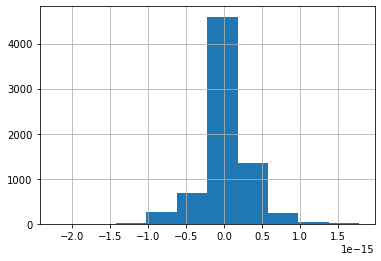

In [16]:
w_pct_diff.hist()

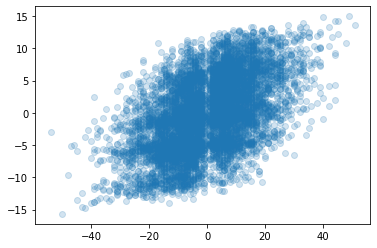

In [13]:
plt.scatter(y_train, y_train_pred, alpha=0.2)

In [14]:
mean_absolute_error(y_train, y_train_pred)

9.31890909909849

In [15]:
y_test_pred = model.predict(X_test)
y_test_pred

array([-10.40401361,   8.86768737,   7.50331672, ...,   3.52799429,
         2.78183129,   2.90583576])

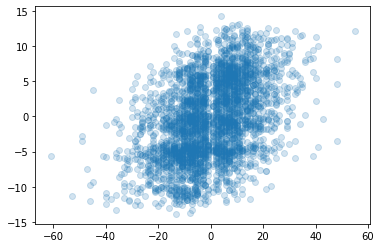

In [16]:
plt.scatter(y_test, y_test_pred, alpha=0.2)

In [17]:
mean_absolute_error(y_test, y_test_pred)

9.687508169299754

## 5.6 Refit Model On All Available Data (excluding Big Mountain)<a id='5.6_Refit_Model_On_All_Available_Data_(excluding_Big_Mountain)'></a>

This next step requires some careful thought. We want to refit the model using all available data. But should we include Big Mountain data? On the one hand, we are _not_ trying to estimate model performance on a previously unseen data sample, so theoretically including Big Mountain data should be fine. One might first think that including Big Mountain in the model training would, if anything, improve model performance in predicting Big Mountain's ticket price. But here's where our business context comes in. The motivation for this entire project is based on the sense that Big Mountain needs to adjust its pricing. One way to phrase this problem: we want to train a model to predict Big Mountain's ticket price based on data from _all the other_ resorts! We don't want Big Mountain's current price to bias this. We want to calculate a price based only on its competitors.

In [18]:
X = X_train
y = y_train

In [19]:
len(X), len(y)

(7186, 7186)

In [20]:
model.fit(X, y)

Pipeline(steps=[('randomforestregressor',
                 RandomForestRegressor(max_depth=5, min_samples_split=50,
                                       n_estimators=200, random_state=47))])

In [21]:
cv_results = cross_validate(model, X, y, scoring='neg_mean_absolute_error', cv=5, n_jobs=-1)

In [22]:
cv_results['test_score']

array([-10.16019764,  -9.52482601,  -9.70118732,  -9.55084614,
        -9.95794302])

<font color='red'> why is there is such large numbers in this test_score? what does it mean? I thought we'd get smaller numbers like in RF_pipe of '04_preprocessing_and_training'<font>

In [23]:
mae_mean, mae_std = np.mean(-1 * cv_results['test_score']), np.std(-1 * cv_results['test_score'])
mae_mean, mae_std

(9.77900002561434, 0.2449676129769277)

These numbers will inevitably be different to those in the previous step that used a different training data set. They should, however, be consistent. It's important to appreciate that estimates of model performance are subject to the noise and uncertainty of data!

## 5.7 Calculate Expected Big Mountain Ticket Price From The Model<a id='5.7_Calculate_Expected_Big_Mountain_Ticket_Price_From_The_Model'></a>

In [24]:
y_test_pred = model.predict(X_test)

In [25]:
y_test_ = y_test.values

In [26]:
print(f'Expected mean absolute error is {mae_mean:.2f} points.')

Expected mean absolute error is 9.78 points.


This result should be looked at optimistically and doubtfully! The validity of our model lies in the assumption that other resorts accurately set their prices according to what the market (the ticket-buying public) supports. The fact that our resort seems to be charging that much less that what's predicted suggests our resort might be undercharging. 
But if ours is mispricing itself, are others? It's reasonable to expect that some resorts will be "overpriced" and some "underpriced." Or if resorts are pretty good at pricing strategies, it could be that our model is simply lacking some key data? Certainly we know nothing about operating costs, for example, and they would surely help.

## 5.8 Big Mountain Resort In Market Context<a id='5.8_Big_Mountain_Resort_In_Market_Context'></a>

Features that came up as important in the modeling (not just our final, random forest model) included:
* w_pct_cma_diff
* away_home_a
* spread_cma_diff
* E_NET_RATING_cma_diff

It's often useful to define custom functions for visualizing data in meaningful ways. The function below takes a feature name as an input and plots a histogram of the values of that feature. It then marks where Big Mountain sits in the distribution by marking Big Mountain's value with a vertical line using `matplotlib`'s [axvline](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.axvline.html) function. It also performs a little cleaning up of missing values and adds descriptive labels and a title.

In [27]:
#Code task 1#
#Add code to the `plot_compare` function that displays a vertical, dashed line
#on the histogram to indicate Big Mountain's position in the distribution
#Hint: plt.axvline() plots a vertical line, its position for 'feature1'
#would be `big_mountain['feature1'].values, we'd like a red line, which can be
#specified with c='r', a dashed linestyle is produced by ls='--',
#and it's nice to give it a slightly reduced alpha value, such as 0.8.
#Don't forget to give it a useful label (e.g. 'Big Mountain') so it's listed
#in the legend.
def plot_compare(feat_name, description, state=None, figsize=(10, 5)):
    """Graphically compare distributions of features.
    
    Plot histogram of values for all resorts and reference line to mark
    Big Mountain's position.
    
    Arguments:
    feat_name - the feature column name in the data
    description - text description of the feature
    state - select a specific state (None for all states)
    figsize - (optional) figure size
    """
    
    plt.subplots(figsize=figsize)
    # quirk that hist sometimes objects to NaNs, sometimes doesn't
    # filtering only for finite values tidies this up
    if state is None:
        ski_x = ski_data[feat_name]
    else:
        ski_x = ski_data.loc[ski_data.state == state, feat_name]
    ski_x = ski_x[np.isfinite(ski_x)]
    plt.hist(ski_x, bins=30)
    plt.axvline(x=big_mountain[feat_name].values, c='r', ls='--', alpha=0.8, label='Big Mountain')
    plt.xlabel(description)
    plt.ylabel('frequency')
    plt.title(description + ' distribution for resorts in market share')
    plt.legend()

### 5.8.1 Ticket price<a id='5.8.1_Ticket_price'></a>

Look at where Big Mountain sits overall amongst all resorts for price and for just other resorts in Montana.

NameError: name 'ski_data' is not defined

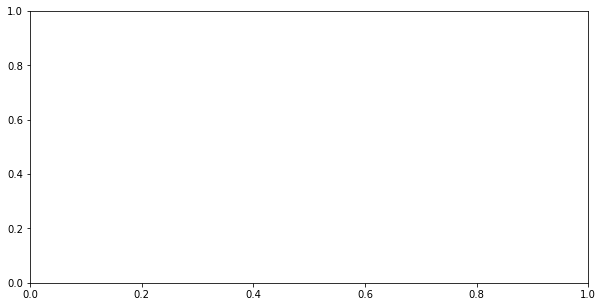

In [28]:
plot_compare('AdultWeekend', 'Adult weekend ticket price ($)')

In [ ]:
plot_compare('AdultWeekend', 'Adult weekend ticket price ($) - Montana only', state='Montana')

### 5.8.2 Vertical drop<a id='5.8.2_Vertical_drop'></a>

In [ ]:
plot_compare('vertical_drop', 'Vertical drop (feet)')

Big Mountain is doing well for vertical drop, but there are still quite a few resorts with a greater drop.

<font color='red'>Big Mountain percentile for vertical drop???????????????<font>

In [ ]:
1 - ski_data[ski_data['vertical_drop'] >= 2353][['Name','vertical_drop']].count() / ski_data['vertical_drop'].count()
#ski_data[['Name','vertical_drop']]

### 5.8.3 Snow making area<a id='5.8.3_Snow_making_area'></a>

In [ ]:
plot_compare('Snow Making_ac', 'Area covered by snow makers (acres)')

Big Mountain is very high up the league table of snow making area.

### 5.8.4 Total number of chairs<a id='5.8.4_Total_number_of_chairs'></a>

In [ ]:
plot_compare('total_chairs', 'Total number of chairs')

Big Mountain has amongst the highest number of total chairs, resorts with more appear to be outliers.

<font color='red'> how were total number of chairs counted????? May the counting method be reason for some of these outliers??????????????????<font> 

In [ ]:
ski_data[ski_data['total_chairs'] > 35 ]['AdultWeekend']

In [ ]:
ski_data[ski_data['total_chairs'] > 35 ]

### 5.8.5 Fast quads<a id='5.8.5_Fast_quads'></a>

In [ ]:
plot_compare('fastQuads', 'Number of fast quads')

Most resorts have no fast quads. Big Mountain has 3, which puts it high up that league table. There are some values  much higher, but they are rare.

<font color='red'>league table??????????????<font>

### 5.8.6 Runs<a id='5.8.6_Runs'></a>

In [ ]:
plot_compare('Runs', 'Total number of runs')

Big Mountain compares well for the number of runs. There are some resorts with more, but not many.

### 5.8.7 Longest run<a id='5.8.7_Longest_run'></a>

In [ ]:
plot_compare('LongestRun_mi', 'Longest run length (miles)')

Big Mountain has one of the longest runs. Although it is just over half the length of the longest, the longer ones are rare.

### 5.8.8 Trams<a id='5.8.8_Trams'></a>

In [ ]:
plot_compare('trams', 'Number of trams')

The vast majority of resorts, such as Big Mountain, have no trams.

### 5.8.9 Skiable terrain area<a id='5.8.9_Skiable_terrain_area'></a>

In [ ]:
plot_compare('SkiableTerrain_ac', 'Skiable terrain area (acres)')

Big Mountain is amongst the resorts with the largest amount of skiable terrain.

<font color='red'>percentile????????????<font>

In [ ]:
X_bm['SkiableTerrain_ac']

In [ ]:
1 - ski_data[ski_data['SkiableTerrain_ac'] >= 3000][['Name','SkiableTerrain_ac']].count() / ski_data['SkiableTerrain_ac'].count()

## 5.9 Modeling scenarios<a id='5.9_Modeling_scenarios'></a>

Big Mountain Resort has been reviewing potential scenarios for either cutting costs or increasing revenue (from ticket prices). Ticket price is not determined by any set of parameters; the resort is free to set whatever price it likes. However, the resort operates within a market where people pay more for certain facilities, and less for others. Being able to sense how facilities support a given ticket price is valuable business intelligence. This is where the utility of our model comes in.

The business has shortlisted some options:
1. Permanently closing down up to 10 of the least used runs. This doesn't impact any other resort statistics.
2. Increase the vertical drop by adding a run to a point 150 feet lower down but requiring the installation of an additional chair lift to bring skiers back up, without additional snow making coverage
3. Same as number 2, but adding 2 acres of snow making cover
4. Increase the longest run by 0.2 mile to boast 3.5 miles length, requiring an additional snow making coverage of 4 acres

The expected number of visitors over the season is 350,000 and, on average, visitors ski for five days. Assume the provided data includes the additional lift that Big Mountain recently installed.

<font color='red'>facilities support a given ticket price?????
    
    
how do we know 1?????????
    
    
    
    
<font>

In [ ]:
expected_visitors = 350_000

In [ ]:
all_feats = ['vertical_drop', 'Snow Making_ac', 'total_chairs', 'fastQuads', 
             'Runs', 'LongestRun_mi', 'trams', 'SkiableTerrain_ac']
big_mountain[all_feats]

In [ ]:
#Code task 2#
#In this function, copy the Big Mountain data into a new data frame
#(Note we use .copy()!)
#And then for each feature, and each of its deltas (changes from the original),
#create the modified scenario dataframe (bm2) and make a ticket price prediction
#for it. The difference between the scenario's prediction and the current
#prediction is then calculated and returned.
#Complete the code to increment each feature by the associated delta
def predict_increase(features, deltas):
    """Increase in modelled ticket price by applying delta to feature.
    
    Arguments:
    features - list, names of the features in the ski_data dataframe to change
    deltas - list, the amounts by which to increase the values of the features
    
    Outputs:
    Amount of increase in the predicted ticket price
    """
    
    bm2 = X_bm.copy()
    for f, d in zip(features, deltas):
        bm2[f] += d
    return model.predict(bm2).item() - model.predict(X_bm).item()

### 5.9.1 Scenario 1<a id='5.9.1_Scenario_1'></a>

Close up to 10 of the least used runs. The number of runs is the only parameter varying.

In [ ]:
[i for i in range(-1, -11, -1)]

In [ ]:
runs_delta = [i for i in range(-1, -11, -1)]
price_deltas = [predict_increase(['Runs'], [delta]) for delta in runs_delta]

In [ ]:
price_deltas

In [ ]:
#Code task 3#
#Create two plots, side by side, for the predicted ticket price change (delta) for each
#condition (number of runs closed) in the scenario and the associated predicted revenue
#change on the assumption that each of the expected visitors buys 5 tickets
#There are two things to do here:
#1 - use a list comprehension to create a list of the number of runs closed from `runs_delta`
#2 - use a list comprehension to create a list of predicted revenue changes from `price_deltas`
runs_closed = [-1 * rc for rc in runs_delta] #1
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.subplots_adjust(wspace=0.5)
ax[0].plot(runs_closed, price_deltas, 'o-')
ax[0].set(xlabel='Runs closed', ylabel='Change ($)', title='Ticket price')
revenue_deltas = [5 * expected_visitors * pd for pd in price_deltas] #2
ax[1].plot(runs_closed, revenue_deltas, 'o-')
ax[1].set(xlabel='Runs closed', ylabel='Change ($)', title='Revenue');

The model says closing one run makes no difference. Closing 2 and 3 successively reduces support for ticket price and so revenue. If Big Mountain closes down 3 runs, it seems they may as well close down 4 or 5 as there's no further loss in ticket price. Increasing the closures down to 6 or more leads to a large drop. 

### 5.9.2 Scenario 2<a id='5.9.2_Scenario_2'></a>

In this scenario, Big Mountain is adding a run, increasing the vertical drop by 150 feet, and installing an additional chair lift.

In [ ]:
#Code task 4#
#Call `predict_increase` with a list of the features 'Runs', 'vertical_drop', and 'total_chairs'
#and associated deltas of 1, 150, and 1
ticket2_increase = predict_increase(['Runs', 'vertical_drop', 'total_chairs'], [1, 150, 1])
revenue2_increase = 5 * expected_visitors * ticket2_increase

In [ ]:
print(f'This scenario increases support for ticket price by ${ticket2_increase:.2f}')
print(f'Over the season, this could be expected to amount to ${revenue2_increase:.0f}')

<font color='red'> not getting the $1.99 and ~3.5 mil as preshown output suggested??????????? different model used????<font>

### 5.9.3 Scenario 3<a id='5.9.3_Scenario_3'></a>

In this scenario, you are repeating the previous one but adding 2 acres of snow making.

In [ ]:
#Code task 5#
#Repeat scenario 2 conditions, but add an increase of 2 to `Snow Making_ac`
ticket3_increase = predict_increase(['Runs', 'vertical_drop', 'total_chairs', 'Snow Making_ac'], [1, 150, 1, 2])
revenue3_increase = 5 * expected_visitors * ticket3_increase

In [ ]:
print(f'This scenario increases support for ticket price by ${ticket3_increase:.2f}')
print(f'Over the season, this could be expected to amount to ${revenue3_increase:.0f}')

Such a small increase in the snow making area makes no difference!

In [ ]:
print(f'percentage profit: {(revenue3_increase - 1500000) / 1500000 * 100}')

### 5.9.4 Scenario 4<a id='5.9.4_Scenario_4'></a>

This scenario calls for increasing the longest run by .2 miles and guaranteeing its snow coverage by adding 4 acres of snow making capability.

In [ ]:
#Code task 6#
#Predict the increase from adding 0.2 miles to `LongestRun_mi` and 4 to `Snow Making_ac`
predict_increase(['LongestRun_mi', 'Snow Making_ac'], [.2, 4])

No difference whatsoever. Although the longest run feature was used in the linear model, the random forest model (the one we chose because of its better performance) only has longest run way down in the feature importance list. 

## 5.10 Summary<a id='5.10_Summary'></a>

**Q: 1** Write a summary of the results of modeling these scenarios. Start by starting the current position; how much does Big Mountain currently charge? What does your modelling suggest for a ticket price that could be supported in the marketplace by Big Mountain's facilities? How would you approach suggesting such a change to the business leadership? Discuss the additional operating cost of the new chair lift per ticket (on the basis of each visitor on average buying 5 day tickets) in the context of raising prices to cover this. For future improvements, state which, if any, of the modeled scenarios you'd recommend for further consideration. Suggest how the business might test, and progress, with any run closures.

**Q: 1** Write a summary of the results of modeling these scenarios. Start by starting the current position; how much does Big Mountain currently charge? What does your modelling suggest for a ticket price that could be supported in the marketplace by Big Mountain's facilities? How would you approach suggesting such a change to the business leadership? Discuss the additional operating cost of the new chair lift per ticket (on the basis of each visitor on average buying 5 day tickets) in the context of raising prices to cover this. For future improvements, state which, if any, of the modeled scenarios you'd recommend for further consideration. Suggest how the business might test, and progress, with any run closures.

**A: 1** Your answer here

Start by starting the current position; how much does Big Mountain currently charge?
<br>-Big Mountain Resort currently charges an 'AdultWeekend' ticket price of $81.00. 

What does your modelling suggest for a ticket price that could be supported in the marketplace by Big Mountain's facilities?
<br>-The modelling suggests 'AdultWeekend' ticket price could be $96.75.

How would you approach suggesting such a change to the business leadership? Discuss the additional operating cost of the new chair lift per ticket (on the basis of each visitor on average buying 5 day tickets) in the context of raising prices to cover this.
<br>-I would approach suggesting a change to the business leadership by speaking about what the data has presented as possible solutions.
<br>-The additional operating cost of adding a chairlift to Big Mountain Resort can be offset by raising the average ticket price for each visitor. -In our ?analysis?, we assume 350,000 visitor per season, each buying an average of 5 day tickets at 81 dollars and therefore a 1.00 dollar increase would yield a 1.75 million dollar income increase.

<br>-Our model shows it would be market competitive (national) to raise the ticket price to by an average of 1.10 dollar. This would yield an annual income increase of 1,927,536 dollars and cover the additional $1,540,000 operating cost for this seasonal.

<br>-Because of Big Mountain's high rank among ticket price predictive categories (i.e. amount of facilities offered), we believe this $1.10 average increase in ticket price is justified given the trend for ticket prices nationally.

For future improvements, state which, if any, of the modeled scenarios you'd recommend for further consideration.
<br>-For future improvements, I would suggest to look more into the scenario of adding another lift while increasing the 'vertical_drop' and increasing the number of 'Runs' at a steady rate.

Suggest how the business might test, and progress, with any run closures.
<br>-Our modeling suggests a small shutdown in number of runs, e.g. 1, should not mean a decrease ticket prices, while the closer of more than that will in stages. We recommend to not to close more than 1 if we are to maximize profits or minimize shutdowns to 3-5 or less.


## 5.11 Further work<a id='5.11_Further_work'></a>

**Q: 2** What next? Highlight any deficiencies in the data that hampered or limited this work. The only price data in our dataset were ticket prices. You were provided with information about the additional operating cost of the new chair lift, but what other cost information would be useful? Big Mountain was already fairly high on some of the league charts of facilities offered, but why was its modeled price so much higher than its current price? Would this mismatch come as a surprise to the business executives? How would you find out? Assuming the business leaders felt this model was useful, how would the business make use of it? Would you expect them to come to you every time they wanted to test a new combination of parameters in a scenario? We hope you would have better things to do, so how might this model be made available for business analysts to use and explore?

**A: 2** Your answer here

**Q: 2** What next? Highlight any deficiencies in the data that hampered or limited this work. The only price data in our dataset were ticket prices. You were provided with information about the additional operating cost of the new chair lift, but what other cost information would be useful? Big Mountain was already fairly high on some of the league charts of facilities offered, but why was its modeled price so much higher than its current price? Would this mismatch come as a surprise to the business executives? How would you find out? Assuming the business leaders felt this model was useful, how would the business make use of it? Would you expect them to come to you every time they wanted to test a new combination of parameters in a scenario? We hope you would have better things to do, so how might this model be made available for business analysts to use and explore?

What next? Highlight any deficiencies in the data that hampered or limited this work. The only price data in our dataset were ticket prices.
<br>-One of the deficiencies in the data included knowing we have 350,000 visitors per season, but not knowing the precise behavior of visitor purchaser behavior like number of day tickets purchased and therefore making an assumption (of 5) on the average number of day tickets purchased per season per vistor.v

You were provided with information about the additional operating cost of the new chair lift, but what other cost information would be useful?
<br>-It would be useful to have information about the location of the this new chair lift in addition to its operating cost. Information of interest about the chair lift per se include speed of chair lift and number of chairs of the chair lift. Other information of interest include elevation spanned by the chairlift and number of runs the chair lift would add to Big Mountain Resort.
<br>-Also, it would be useful to have information about the number of tickets each person purchased each season.


Big Mountain was already fairly high on some of the league charts of facilities offered, but why was its modeled price so much higher than its current price?
<br>-Big Mountain's model price was higher than it's current price maybe because the state of Montana charges less for vistor day ticket.

Would this mismatch come as a surprise to the business executives? 
<br>-Maybe

How would you find out?
<br>-by asking

Assuming the business leaders felt this model was useful, how would the business make use of it? 
<br>-They could look into increasing vertical_drop, Snow Making_ac, total_chairs, fastQuads, Runs, LongestRun_mi, trams, and/or SkiableTerrain_ac and see if it would be the desireable and profitable to take on that scenario using our model.

Would you expect them to come to you every time they wanted to test a new combination of parameters in a scenario?
<br>-Maybe

We hope you would have better things to do, so how might this model be made available for business analysts to use and explore?
<br>-This model can be used and shared via github or other software for business analysts to use and explored.